In [1]:
# Calculate titers of MHCII-pseudotyped lentiviruses

import os
import warnings

import math
import numpy as np 

from IPython.display import display, HTML
import matplotlib.pyplot as plt

from neutcurve.colorschemes import CBMARKERS, CBPALETTE
from mizani.formatters import scientific_format

import pandas as pd
from plotnine import *

import altair as alt


import yaml

In [2]:
warnings.simplefilter('ignore')

Read config


In [3]:
titers = pd.read_csv('virus_titer_RLU.csv')

titers = (titers
          .assign(RLUperuL=lambda x: x['RLU_per_well'] / x['uL_virus']
                 )
         )

display(HTML(titers.head().to_html(index=False)))

replicate,virus,dilution,uL_virus,RLU_per_well,cells,RLUperuL
rep1,bald eagle,0.50000,50.000,3410000.0,M3-Wigeon-H5,68200.0
rep1,bald eagle,0.25000,25.000,1339000.0,M3-Wigeon-H5,53560.0
rep1,bald eagle,0.12500,12.500,722000.0,M3-Wigeon-H5,57760.0
rep1,bald eagle,0.06250,6.250,310600.0,M3-Wigeon-H5,49696.0
rep1,bald eagle,0.03125,3.125,142600.0,M3-Wigeon-H5,45632.0


In [4]:
ncol=min(8, titers['virus'].nunique())
nrow=math.ceil(titers['virus'].nunique() / ncol)

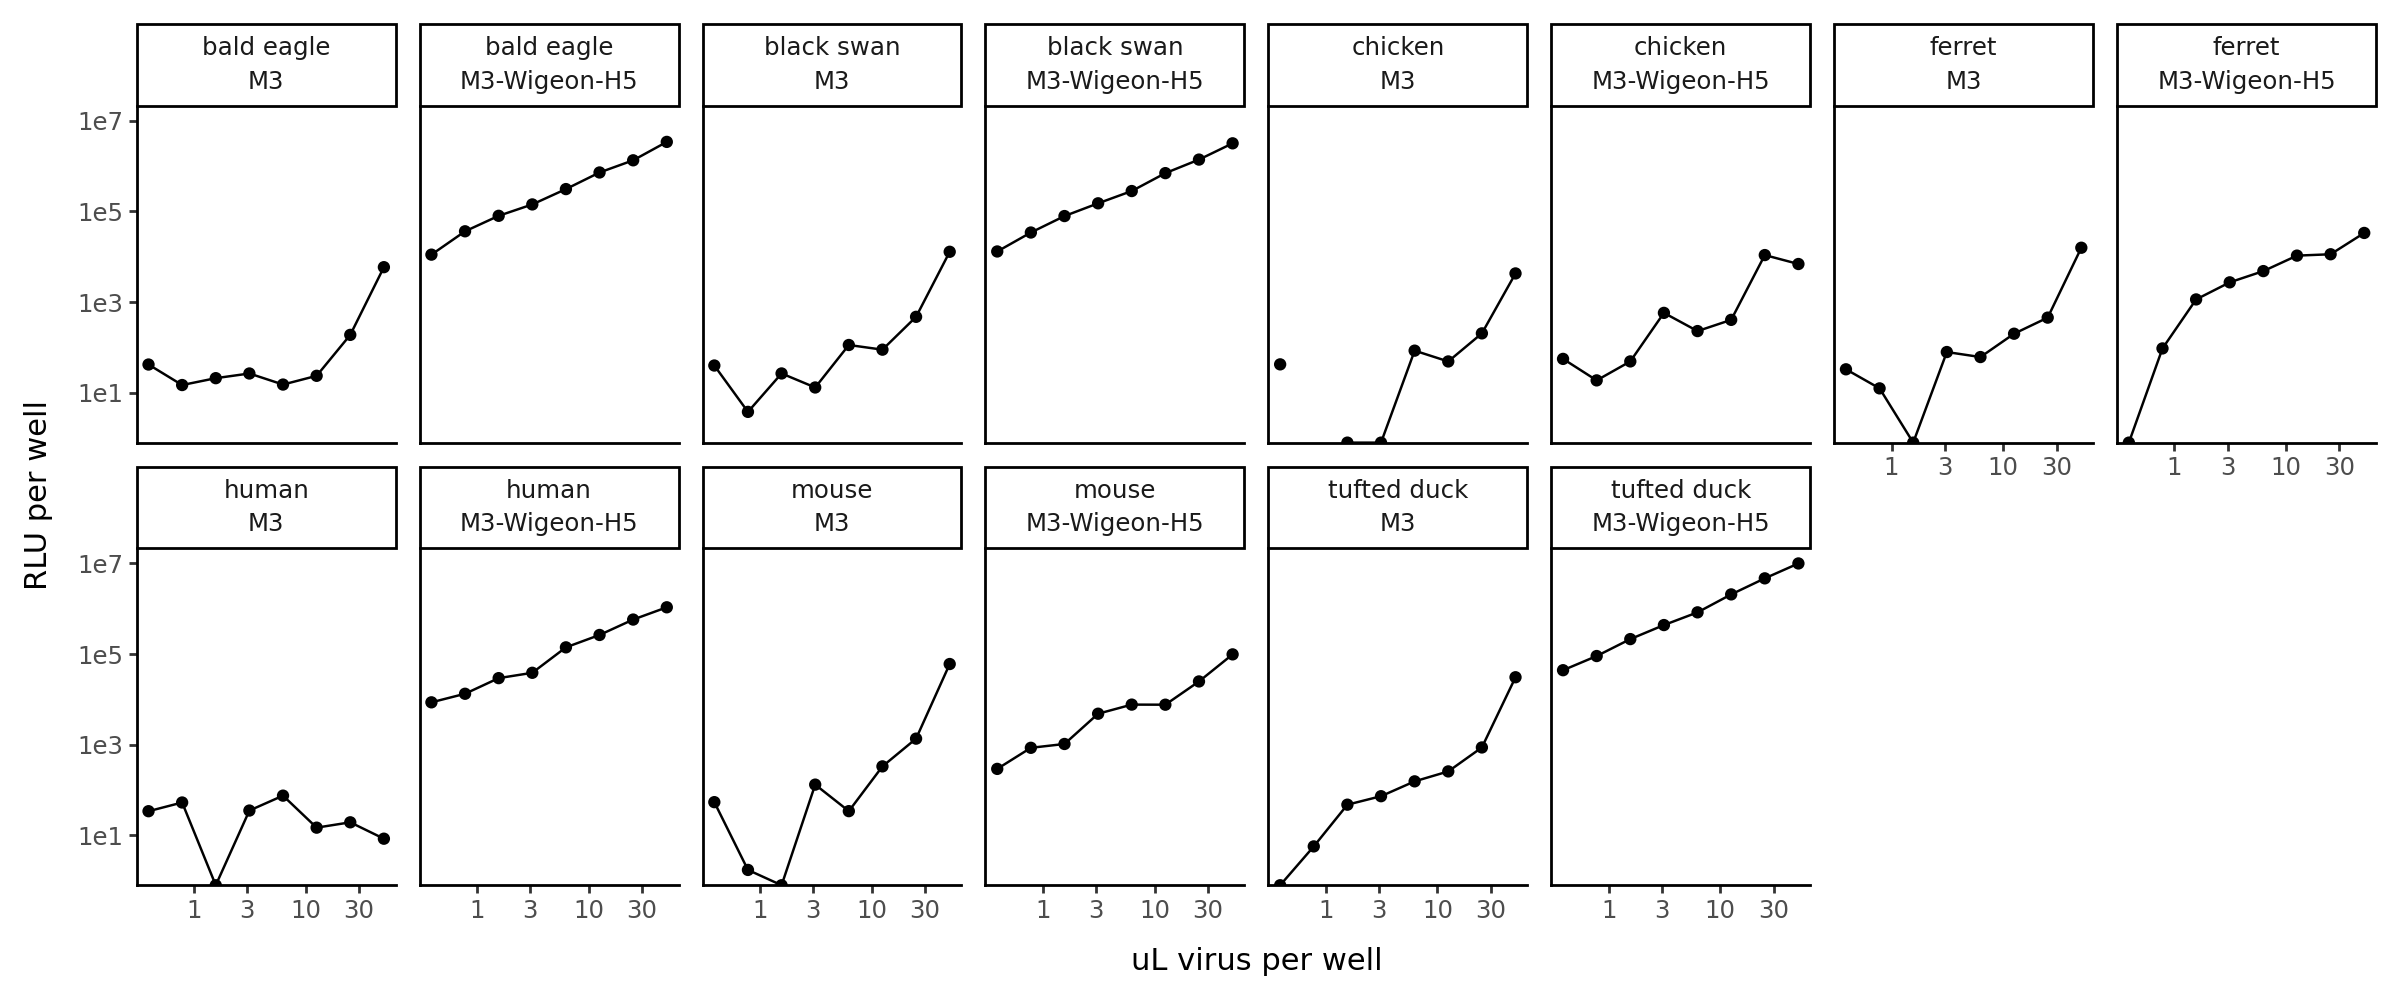

In [5]:
p = (ggplot(titers.dropna()
            ) +
     aes('uL_virus', 'RLU_per_well') +
     geom_point(size=1.5) +
     geom_line() +
     facet_wrap('~virus+cells', ncol=8) +
     scale_y_log10(name='RLU per well') +
     scale_x_log10(name='uL virus per well') +
     theme_classic() +
     theme(axis_text_x=element_text(),
           figure_size=(12,5),
           )
     )

p

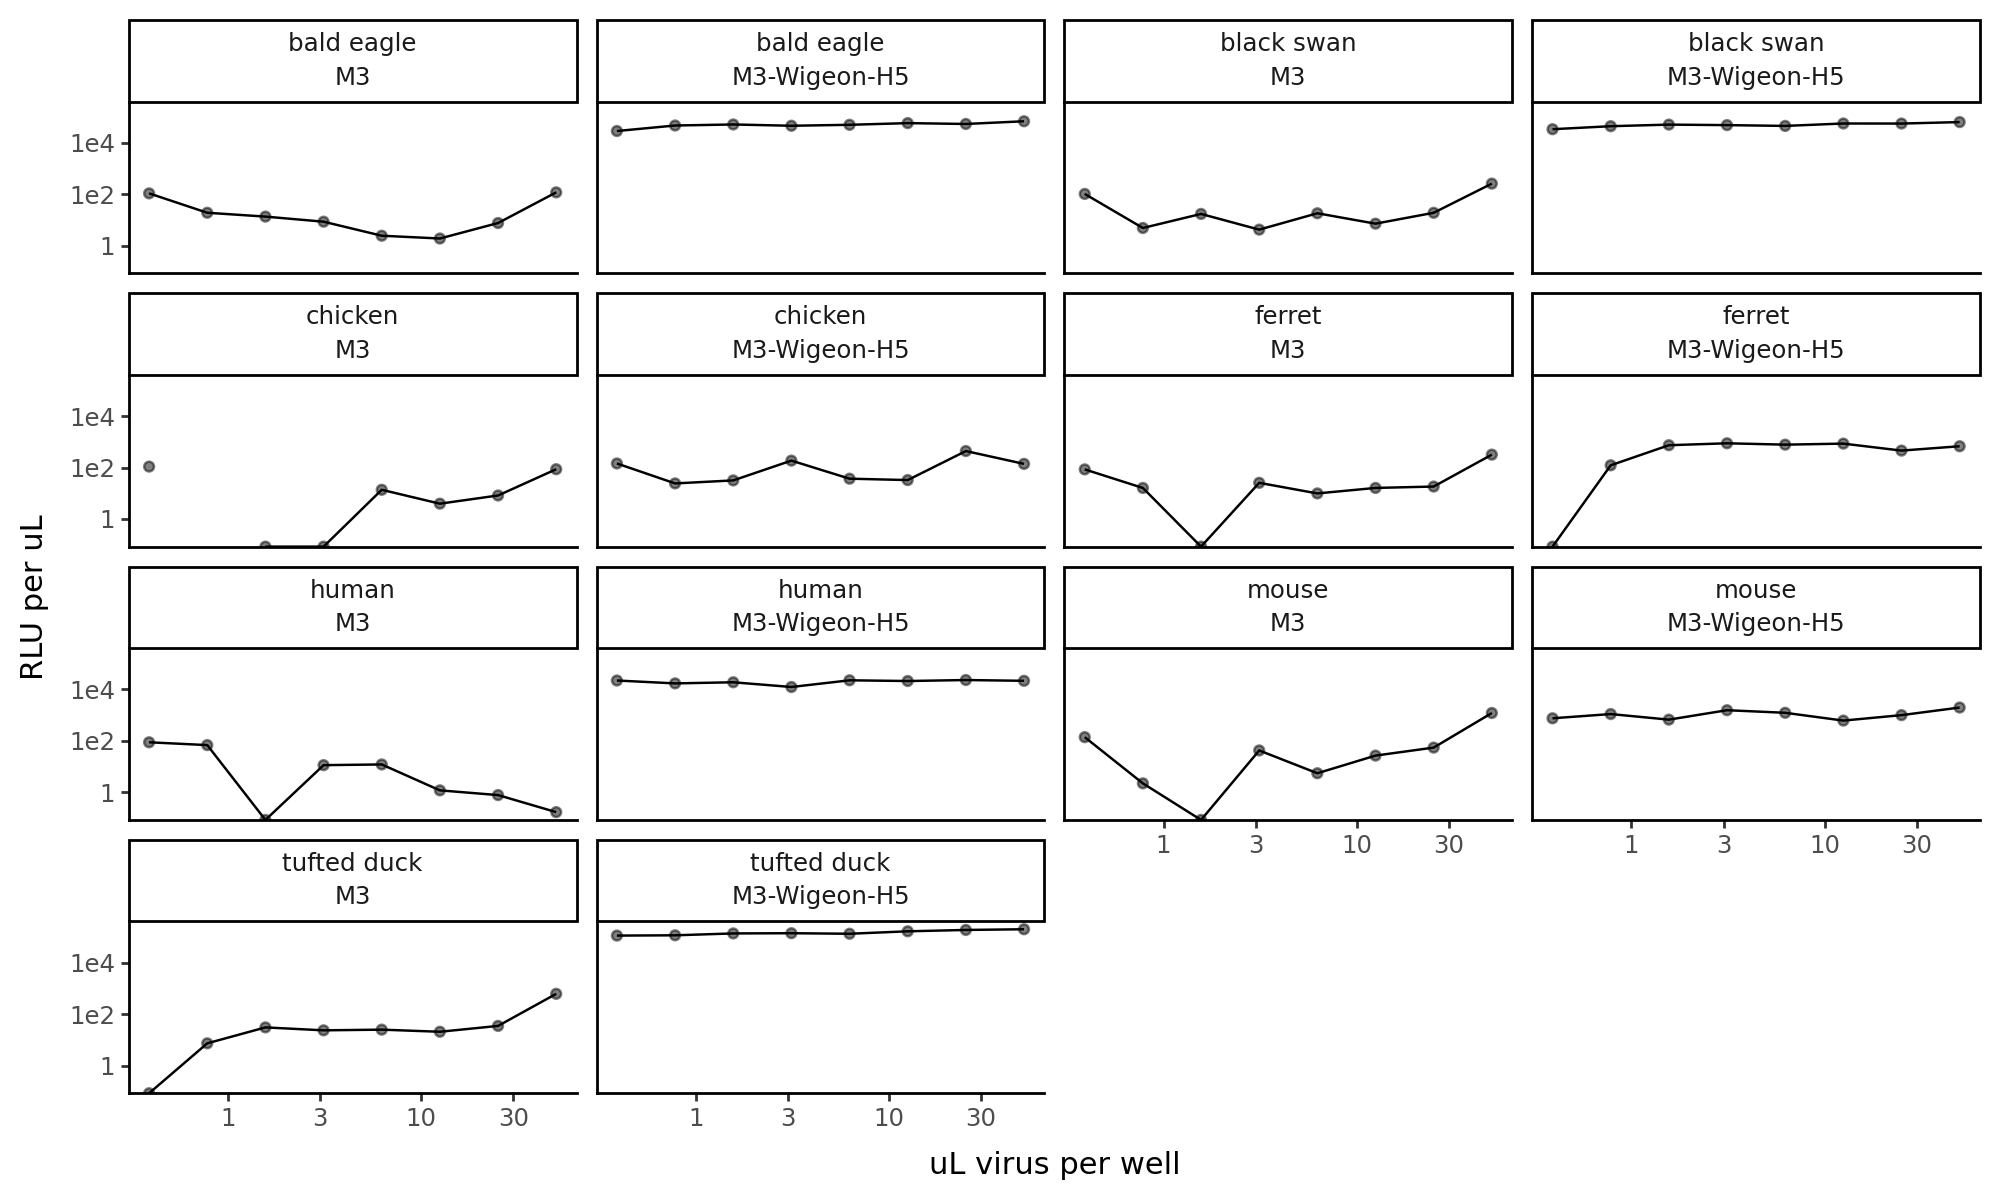

In [6]:
p = (ggplot(titers.dropna()
            ) +
     aes('uL_virus', 'RLUperuL', group='replicate') +
     geom_point(size=1.5, alpha=0.5) +
     geom_line() +
     facet_wrap('~virus+cells', ncol=4) +
     scale_y_log10(name='RLU per uL') +
     scale_x_log10(name='uL virus per well') +
     theme_classic() +
     theme(axis_text_x=element_text(),
           figure_size=(10,6),
           ) 
     )

p

Check that above plots are approximately linear 

In [7]:
average_titers = (titers
                  .dropna() # missing values for some replicates
                  .query('uL_virus > 2') # drop concentrations that would not be linear
                  .groupby(['virus', "cells"])
                  .agg(mean_RLUperuL=pd.NamedAgg(column='RLUperuL', aggfunc=np.mean))
                  .reset_index()
                 )

display(HTML(average_titers.to_html(index=False)))

virus,cells,mean_RLUperuL
bald eagle,M3,27.674240
bald eagle,M3-Wigeon-H5,54969.600000
black swan,M3,61.218720
black swan,M3-Wigeon-H5,53626.400000
chicken,M3,22.318560
chicken,M3-Wigeon-H5,165.847200
ferret,M3,77.192000
ferret,M3-Wigeon-H5,723.936000
human,M3,5.111708
human,M3-Wigeon-H5,20072.960000


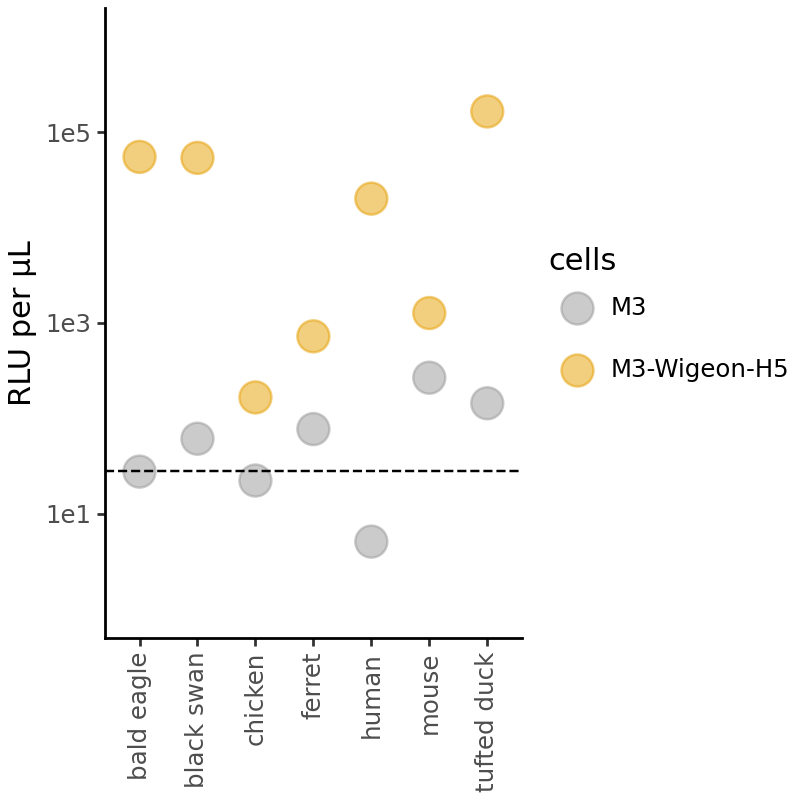

In [8]:
p = (ggplot(average_titers, 
            aes(x='virus', y='mean_RLUperuL', color= "cells")
           ) +
     geom_point(size=6, alpha=0.5)+
     theme_classic() +
     theme(axis_text_x=element_text(angle=90, vjust=1, hjust=0.5),
           axis_title_x=element_blank(),
           figure_size=(4,4),
          ) +
     scale_y_log10(limits=[1,1e6]) +
     ylab('RLU per µL')+
     scale_color_manual(values=CBPALETTE)+
     geom_hline(yintercept=28, linetype="dashed", color="black")

    )

p

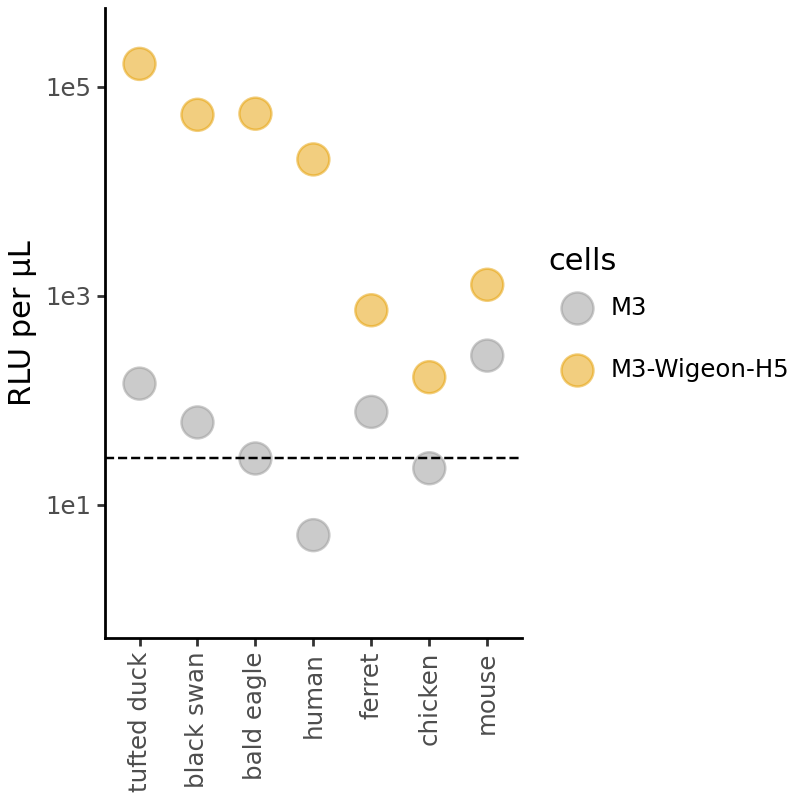

In [9]:


virus_order = [
    "tufted duck",
    "black swan",
    "bald eagle",
    "human",
    "ferret",
    "chicken",
    "mouse"
]

p = (ggplot(average_titers, 
            aes(x='virus', y='mean_RLUperuL', color="cells"))
     + geom_point(size=6, alpha=0.5)
     + theme_classic()
     + theme(
         axis_text_x=element_text(angle=90, vjust=1, hjust=0.5),
         axis_title_x=element_blank(),
         figure_size=(4, 4),
     )
     + scale_x_discrete(limits=virus_order)
     + scale_y_log10(limits=[1, 3e5])
     + ylab('RLU per µL')
     + scale_color_manual(values=CBPALETTE)
     + geom_hline(yintercept=28, linetype="dashed", color="black")
)

p


In [17]:
p = (
    alt.Chart(average_titers)
    .mark_point(size=350, opacity=0.7, filled=True)
    .encode(
        x=alt.X(
            "virus:N",
            sort=virus_order,
            title=None,
            axis=alt.Axis(
                labelAngle=-90,
                labelFontSize=14,
            ),
        ),
        y=alt.Y(
            "mean_RLUperuL:Q",
            scale=alt.Scale(type="log", domain=[1, 3e5]),
            title="RLU per µL",
            axis=alt.Axis(
                labelFontSize=14,
                titleFontSize=16,
                format=".0e",   # shows ticks like 1e+04
            ),
        ),
        color=alt.Color(
            "cells:N",
            scale=alt.Scale(range=CBPALETTE),
            title="cells",
            legend=alt.Legend(
                labelFontSize=14,
                titleFontSize=15,
            ),
        ),
    )
    .properties(width=350, height=350)
)

p = (
    (p )
    .configure_axis(
        grid=False,
        labelFontSize=14,
        titleFontSize=16,
    )
    .configure_legend(
        labelFontSize=14,
        titleFontSize=15,
    )
    .configure_view(
        stroke=None
    )
)

p

alt.Chart(...)

In [11]:
average_titers.head()

,virus,cells,mean_RLUperuL
0,bald eagle,M3,27.67424
1,bald eagle,M3-Wigeon-H5,54969.60000
2,black swan,M3,61.21872
3,black swan,M3-Wigeon-H5,53626.40000
4,chicken,M3,22.31856


In [14]:
fold_change = (
    average_titers
    .pivot(
        index="virus",
        columns="cells",
        values="mean_RLUperuL"
    )
    .reset_index()
    .rename(columns={
        "M3": "M3_RLU",
        "M3-Wigeon-H5": "M3_Wigeon_H5_RLU",
    })
)

fold_change["fold_change"] = (
    fold_change["M3_Wigeon_H5_RLU"] / fold_change["M3_RLU"]
)

In [16]:
p = (
    alt.Chart(fold_change)
    .mark_point(size=350, opacity=0.8, filled=True)
    .encode(
        x=alt.X(
            "virus:N",
            sort=virus_order,
            title=None,
            axis=alt.Axis(
                labelAngle=-90,
                labelFontSize=16,
            ),
        ),
        y=alt.Y(
            "fold_change:Q",
            scale=alt.Scale(type="log"),
            title="Fold change in RLU per uL",
            axis=alt.Axis(
                labelFontSize=16,
                titleFontSize=18,
                format=".0e",
            ),
        ),
        tooltip=[
            alt.Tooltip("virus:N", title="virus"),
            alt.Tooltip("M3_RLU:Q", title="M3", format=".2f"),
            alt.Tooltip("M3_Wigeon_H5_RLU:Q", title="M3-Wigeon-H5", format=".2f"),
            alt.Tooltip("fold_change:Q", title="fold change", format=".2f"),
        ],
    )
    .properties(width=350, height=350)
    .configure_axis(
        grid=False,
        labelFontSize=16,
        titleFontSize=18,
    )
    .configure_view(
        stroke=None
    )
)

p

alt.Chart(...)